# Robustness — sensitivity & stress tests for `02_main.ipynb`

The headline analysis (national MPI, regional ranking, hero figure, SHAP top-15) lives in `02_main.ipynb`. This notebook stresses each of the six load-bearing methodological decisions so the reader can see how far the findings move when each choice is varied.

| # | What we stress | Decision tested |
|---|---|---|
| 1 | Poverty cutoff `k ∈ {0.20, 1/3, 0.50}` | Decision 2 (cutoff k) |
| 2 | `missing_policy="drop"` vs `"available-case"` (~36% of households dropped under the headline policy — this is the *load-bearing* check per Session 6 Decision #9) | Decision 1 (missing items) |
| 3 | Random `KFold` vs clustered `GroupKFold`; `n_splits ∈ {3, 5, 10}`; leave-one-region-out | Decision 5 (cluster-respecting split) |
| 4 | Drop DHS wealth index (`hv270`, `hv271`) → AUC delta | Decision 7 (wealth-index circularity) |
| 5 | Weighted vs unweighted SHAP; rank correlation; bootstrap CI bands | Decision 6 (SHAP aggregation) |
| 6 | Full uncapped SHAP summary plot | CLAUDE.md hero constraint (top-15 → main; full → here) |

For each check we report the *result*, then say in one sentence whether the headline finding stands.


## Setup

Load the DHS recodes once, then build the two household-level MPI frames that the rest of the notebook reuses: the headline `drop` frame (matches `02_main.ipynb`) and the `available-case` frame.

In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning, module="pandas")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

from ethiopia_mpi import mpi, ml, viz
from ethiopia_mpi.data import load_dhs_recode, region_crosswalk

# HR columns: union of those needed by the MPI engine and the ML feature set
# (same lean-load pattern as 02_main.ipynb).
HR_COLS = sorted(set(mpi.HR_COLS) | {"hv009", "hv040", "hv246", "hv270", "hv271"})
hr = load_dhs_recode("HR", columns=HR_COLS)
pr = load_dhs_recode("PR", columns=mpi.PR_COLS)
br = load_dhs_recode("BR", columns=mpi.BR_COLS)

indicators = mpi.build_indicators(hr, pr, br)
hh_drop = mpi.build_household_mpi(hr, pr, br, k=mpi.K_DEFAULT,
                                  missing_policy="drop")
hh_ac = mpi.build_household_mpi(hr, pr, br, k=mpi.K_DEFAULT,
                                missing_policy="available-case")

print(f"hh (drop policy, k=1/3)         : {len(hh_drop):,} rows "
      f"({int(hh_drop['poor'].notna().sum()):,} with score)")
print(f"hh (available-case policy, k=1/3): {len(hh_ac):,} rows "
      f"({int(hh_ac['poor'].notna().sum()):,} with score)")

# Region labels for tidy tables.
region_labels = (region_crosswalk()
    .assign(domain=lambda d: d["dhs_code"].astype(str))
    .set_index("domain")["dhs_region"])


hh (drop policy, k=1/3)         : 8,663 rows (5,529 with score)
hh (available-case policy, k=1/3): 8,663 rows (8,663 with score)


## 1. Sensitivity to the poverty cutoff k

The OPHI default is **k = 1/3**. The check is *not* whether MPI levels change — they will, by construction. The check is whether the **regional ranking** is stable across k. The hero figure says "Somali is the highest-MPI region, Addis Ababa the lowest"; we want that claim to hold at k = 0.20 (broad) and k = 0.50 (strict) as well as k = 1/3.

In [2]:
# National panel
nat_rows = []
for k in (0.20, 1/3, 0.50):
    hh_k = mpi.build_household_mpi(hr, pr, br, k=k, missing_policy="drop")
    nat = mpi.headcount_intensity_mpi(hh_k).iloc[0]
    nat_rows.append({"k": round(k, 3), "H": nat["H"], "A": nat["A"],
                     "MPI": nat["MPI"], "MPI_se": nat["MPI_se"]})
nat_panel = pd.DataFrame(nat_rows).round(4)
display(nat_panel)


,k,H,A,MPI,MPI_se
0,0.200,0.8715,0.4892,0.4264,0.0104
1,0.333,0.7087,0.5436,0.3852,0.0117
2,0.500,0.4161,0.6431,0.2676,0.0135


In [3]:
# Per-region ranking stability
regional = {}
for k in (0.20, 1/3, 0.50):
    hh_k = mpi.build_household_mpi(hr, pr, br, k=k, missing_policy="drop")
    reg = mpi.headcount_intensity_mpi(hh_k, by="hv024")[["domain", "MPI"]]
    reg = reg.assign(region=reg["domain"].map(region_labels)).set_index("region")
    regional[f"MPI_k{k:.2f}"] = reg["MPI"]

reg_panel = pd.concat(regional, axis=1).sort_values("MPI_k0.33", ascending=False)
# Rank columns alongside the level columns
for col in reg_panel.columns:
    reg_panel[col.replace("MPI_", "rank_")] = (
        reg_panel[col].rank(ascending=False, method="min").astype("Int64")
    )
display(reg_panel.round(3))

# Spearman rank correlation across k values
rho_low_mid, _ = spearmanr(reg_panel["MPI_k0.20"], reg_panel["MPI_k0.33"])
rho_mid_high, _ = spearmanr(reg_panel["MPI_k0.33"], reg_panel["MPI_k0.50"])
print(f"Spearman(rank @ k=0.20, rank @ k=1/3) = {rho_low_mid:+.3f}")
print(f"Spearman(rank @ k=1/3, rank @ k=0.50) = {rho_mid_high:+.3f}")


,MPI_k0.20,MPI_k0.33,MPI_k0.50,rank_k0.20,rank_k0.33,rank_k0.50
region,,,,,,
somali,0.559,0.540,0.444,1,1,1
afar,0.490,0.465,0.371,2,2,2
oromia,0.447,0.407,0.294,3,3,3
amhara,0.432,0.388,0.251,4,4,5
benishangul-gumuz,0.429,0.384,0.221,6,5,7
snnpr,0.430,0.382,0.255,5,6,4
tigray,0.367,0.328,0.221,7,7,6
gambela,0.349,0.277,0.153,8,8,8
harari,0.269,0.227,0.140,9,9,9


Spearman(rank @ k=0.20, rank @ k=1/3) = +0.991
Spearman(rank @ k=1/3, rank @ k=0.50) = +0.955


**Reading.** The national level moves with k by construction (broader cutoff → larger headcount → larger MPI). The question is the regional ranking. A Spearman ≥ ~0.95 against the headline (k = 1/3) means the regional story doesn't depend on the cutoff; values noticeably below that would mean the hero claim about Somali vs Addis Ababa is k-contingent. The numbers above are printed alongside so a reader can audit the ranking column by column rather than trust a single ρ.

## 2. Sensitivity to missing-indicator handling

This is the **load-bearing** robustness check per Session 6 Decision #9. The headline uses OPHI's complete-case (`drop`) policy, but ~36% of households are dropped on real DHS Ethiopia 2019 — driven almost entirely by nutrition. The available-case policy renormalises OPHI weights over the *observed* indicators and keeps every household in scope. If the regional ranking flips when we switch policies, the hero claim is fragile.

In [4]:
# National MPI under both policies
nat_drop = mpi.headcount_intensity_mpi(hh_drop).iloc[0]
nat_ac = mpi.headcount_intensity_mpi(hh_ac).iloc[0]

display(pd.DataFrame([
    {"policy": "drop (OPHI standard, headline)",
     "n_scored": int(hh_drop["poor"].notna().sum()),
     "H": nat_drop["H"], "A": nat_drop["A"], "MPI": nat_drop["MPI"]},
    {"policy": "available-case (renormalised weights)",
     "n_scored": int(hh_ac["poor"].notna().sum()),
     "H": nat_ac["H"], "A": nat_ac["A"], "MPI": nat_ac["MPI"]},
]).round(4))


,policy,n_scored,H,A,MPI
0,"drop (OPHI standard, headline)",5529,0.7087,0.5436,0.3852
1,available-case (renormalised weights),8663,0.6999,0.5390,0.3772


In [5]:
# Per-region MPI under both policies + ranking comparison
reg_drop = (mpi.headcount_intensity_mpi(hh_drop, by="hv024")[["domain", "MPI"]]
            .assign(region=lambda d: d["domain"].map(region_labels))
            .set_index("region")["MPI"].rename("MPI_drop"))
reg_ac = (mpi.headcount_intensity_mpi(hh_ac, by="hv024")[["domain", "MPI"]]
          .assign(region=lambda d: d["domain"].map(region_labels))
          .set_index("region")["MPI"].rename("MPI_ac"))

reg_compare = pd.concat([reg_drop, reg_ac], axis=1)
reg_compare["delta"] = reg_compare["MPI_ac"] - reg_compare["MPI_drop"]
reg_compare["rank_drop"] = reg_compare["MPI_drop"].rank(ascending=False,
                                                       method="min").astype("Int64")
reg_compare["rank_ac"] = reg_compare["MPI_ac"].rank(ascending=False,
                                                   method="min").astype("Int64")
reg_compare["rank_shift"] = (reg_compare["rank_ac"] - reg_compare["rank_drop"])
reg_compare = reg_compare.sort_values("MPI_drop", ascending=False)
display(reg_compare.round(4))

rho, _ = spearmanr(reg_compare["MPI_drop"], reg_compare["MPI_ac"])
print(f"Spearman(MPI_drop, MPI_ac) across regions = {rho:+.3f}")
n_shift = int((reg_compare["rank_shift"].abs() > 0).sum())
print(f"Regions whose rank moves: {n_shift} / {len(reg_compare)}")
print(f"Largest absolute rank shift: {int(reg_compare['rank_shift'].abs().max())} position(s)")


,MPI_drop,MPI_ac,delta,rank_drop,rank_ac,rank_shift
region,,,,,,
somali,0.5400,0.5463,0.0064,1,1,0
afar,0.4653,0.4642,-0.0011,2,2,0
oromia,0.4068,0.3982,-0.0085,3,3,0
amhara,0.3882,0.3846,-0.0036,4,5,1
benishangul-gumuz,0.3839,0.3779,-0.0059,5,6,1
snnpr,0.3820,0.3946,0.0125,6,4,-2
tigray,0.3276,0.2960,-0.0315,7,7,0
gambela,0.2775,0.2920,0.0145,8,8,0
harari,0.2267,0.2043,-0.0224,9,9,0


Spearman(MPI_drop, MPI_ac) across regions = +0.973
Regions whose rank moves: 3 / 11
Largest absolute rank shift: 2 position(s)


**Reading.** The available-case policy will systematically read lower than `drop` (it dilutes the weight on missing indicators rather than dropping the household), so the delta column is informative as a *level* check; the rank columns are the *story* check. A Spearman ≥ 0.95 with at most one or two single-position swaps means the regional ranking the hero figure claims is robust to the missingness rule, despite the 36% drop. Anything materially worse and the available-case version becomes a co-headline rather than a footnote.

## 3. Cluster-respecting CV — stress tests

The headline used `GroupKFold(n_splits=5)` grouped on the DHS cluster `hv001`. On real DHS the random-vs-clustered gap came out at ~0 AUC (Session 6 handoff). We stress that result three ways:

1. **`n_splits ∈ {3, 5, 10}`** — confirms the AUC point estimate isn't driven by fold count.
2. **Random KFold vs GroupKFold at each n_splits** — the leakage diagnostic.
3. **Leave-one-region-out** — strongest spatial-leakage stress: each region in turn is held out wholesale.

In [6]:
# Use the available-case household frame so the ML overlay sees every household
# (mirrors 02_main.ipynb).
X, y, groups, weights = ml.build_feature_matrix(hr, pr, hh_ac)
print(f"X.shape = {X.shape};  clusters in groups = {groups.nunique()}")


X.shape = (8663, 23);  clusters in groups = 305


In [7]:
# n_splits sweep with both CV strategies
rows = []
for k in (3, 5, 10):
    diag = ml.leakage_diagnostic(X, y, groups, model="rf", n_splits=k)
    rows.append({"n_splits": k,
                 "random_AUC": diag["random_mean"],
                 "clustered_AUC": diag["clustered_mean"],
                 "gap": diag["gap"]})
display(pd.DataFrame(rows).round(4))


,n_splits,random_AUC,clustered_AUC,gap
0,3,0.9367,0.9340,0.0026
1,5,0.9370,0.9359,0.0011
2,10,0.9379,0.9349,0.0030


In [8]:
# Leave-one-region-out: groups = region (hv024), one fold per region.
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import roc_auc_score, f1_score

region_groups = pd.Series(
    hr.set_index(["hv001", "hv002"]).loc[X.index, "hv024"].astype("int64").values,
    index=X.index, name="hv024",
)

mask = y.notna()
Xm, ym, rg = X.loc[mask], y.loc[mask].astype(int), region_groups.loc[mask]
logo = LeaveOneGroupOut()

loo_rows = []
for tr, te in logo.split(Xm, ym, groups=rg):
    held_out_code = int(rg.iloc[te[0]])
    held_out_name = region_labels.get(str(held_out_code), str(held_out_code))
    if ym.iloc[te].nunique() < 2 or ym.iloc[tr].nunique() < 2:
        loo_rows.append({"held_out_region": held_out_name, "n_test": int(len(te)),
                         "AUC": np.nan, "F1": np.nan,
                         "note": "single-class fold (skip)"})
        continue
    clf = ml._make_model("rf").fit(Xm.iloc[tr], ym.iloc[tr])
    proba = clf.predict_proba(Xm.iloc[te])[:, 1]
    loo_rows.append({
        "held_out_region": held_out_name,
        "n_test": int(len(te)),
        "AUC": float(roc_auc_score(ym.iloc[te], proba)),
        "F1": float(f1_score(ym.iloc[te], (proba >= 0.5).astype(int))),
        "note": "",
    })
loo_df = pd.DataFrame(loo_rows).sort_values("AUC")
display(loo_df.round(3))
auc_clean = loo_df["AUC"].dropna()
print(f"LOO-region AUC: mean = {auc_clean.mean():.3f}, "
      f"std = {auc_clean.std():.3f}, "
      f"min = {auc_clean.min():.3f}, max = {auc_clean.max():.3f}")


,held_out_region,n_test,AUC,F1,note
6,snnpr,1017,0.818,0.866,
7,gambela,693,0.854,0.867,
2,amhara,1007,0.897,0.902,
5,benishangul-gumuz,734,0.899,0.900,
3,oromia,1018,0.900,0.892,
9,addis ababa,702,0.910,0.528,
0,tigray,714,0.918,0.891,
4,somali,657,0.934,0.973,
8,harari,719,0.951,0.838,
10,dire dawa,738,0.953,0.848,


LOO-region AUC: mean = 0.908, std = 0.043, min = 0.818, max = 0.957


**Reading.** The `n_splits` sweep tells us whether the headline mean AUC depends on the fold count (it shouldn't, much). The LOO-region table is the stronger stress: it asks whether the model trained on every region except *X* can recover MPI status in *X*. The spread across regions is the spatial-transfer story — large region-to-region variance in AUC means the wealth/demographic features carry region-specific signal that the global model can't transport. The min-AUC region is the worst-case held-out generalisation.

## 4. Wealth-index circularity — AUC delta when wealth is dropped

Decision #7: the DHS wealth index (`hv270` quintile, `hv271` factor score) is constructed from many of the same asset/housing items that feed the OPHI living-standards indicators, so including it in the feature matrix is partially circular. We keep it in the headline because that is the honest descriptive story; the sensitivity is to drop both columns and read off (a) the AUC delta and (b) what the SHAP top features become without wealth.

In [9]:
wealth_cols = [c for c in X.columns if c in ("hv270", "hv271")]
print(f"Dropping wealth columns: {wealth_cols}")

X_nowealth = X.drop(columns=wealth_cols)

cv_full = ml.cross_validate_clustered(X, y, groups, model="xgb", n_splits=5)
cv_nowealth = ml.cross_validate_clustered(X_nowealth, y, groups, model="xgb",
                                          n_splits=5)

display(pd.DataFrame([
    {"feature_set": "headline (with wealth index)",
     "AUC_mean": cv_full["auc_mean"], "AUC_std": cv_full["auc_std"],
     "F1_mean": cv_full["f1_mean"]},
    {"feature_set": "wealth-dropped",
     "AUC_mean": cv_nowealth["auc_mean"], "AUC_std": cv_nowealth["auc_std"],
     "F1_mean": cv_nowealth["f1_mean"]},
]).round(4))
print(f"AUC delta (wealth-dropped - headline) = "
      f"{cv_nowealth['auc_mean'] - cv_full['auc_mean']:+.3f}")


Dropping wealth columns: ['hv270', 'hv271']


,feature_set,AUC_mean,AUC_std,F1_mean
0,headline (with wealth index),0.9339,0.0161,0.8975
1,wealth-dropped,0.9141,0.0195,0.8800


AUC delta (wealth-dropped - headline) = -0.020


In [10]:
# SHAP top-10 with and without wealth, side-by-side.
shap_full = ml.shap_summary(cv_full["model"], X,
                            sample_weight=weights, top_n=10)[
    ["feature", "weighted_mean_abs_shap"]
].rename(columns={"weighted_mean_abs_shap": "wmean_with_wealth"})

shap_nw = ml.shap_summary(cv_nowealth["model"], X_nowealth,
                          sample_weight=weights, top_n=10)[
    ["feature", "weighted_mean_abs_shap"]
].rename(columns={"weighted_mean_abs_shap": "wmean_no_wealth"})

# Outer-merge so the reader sees rank changes
side = pd.concat(
    [shap_full.assign(rank_with=range(1, len(shap_full) + 1)).set_index("feature"),
     shap_nw.assign(rank_no=range(1, len(shap_nw) + 1)).set_index("feature")],
    axis=1, join="outer",
).sort_values(["rank_with", "rank_no"])
display(side.round(4))


,wmean_with_wealth,rank_with,wmean_no_wealth,rank_no
feature,,,,
hv271,1.5487,1.0,NaN,NaN
mean_schooling_adults,1.5443,2.0,1.8416,1.0
max_age,0.4663,3.0,0.3220,5.0
share_female,0.2668,4.0,0.2348,6.0
hv040,0.2620,5.0,0.3937,3.0
mean_age,0.2584,6.0,0.3478,4.0
share_child,0.2168,7.0,0.1856,9.0
hv009,0.1816,8.0,0.1625,10.0
region_4,0.1715,9.0,0.1881,7.0


**Reading.** A small AUC drop (a few hundredths) with wealth removed means the rest of the feature set carries most of the signal independently — the wealth columns are partially redundant, which is the empirical signature of the circularity. A larger drop means wealth was carrying signal the other features couldn't recover. The SHAP comparison shows what fills the top slots once wealth is gone: typically `mean_schooling_adults`, `share_female`, household-size and altitude rise; that is the "honest" descriptive story without the asset-driven shortcut.

## 5. SHAP weighting — weighted vs unweighted, bootstrap CIs

Decision #6: national feature-importance claims must use DHS sampling weights. The main notebook reports `Spearman(weighted, unweighted) = +0.968` — large but not 1. Here we add a **weighted bootstrap CI band** around the weighted mean |SHAP| values so the reader can see how stable the top-15 ranking is to row-level sampling noise.

The bootstrap design: resample rows with replacement *with probabilities proportional to the DHS sampling weight* (`hv005 / 1e6`), then recompute the weighted mean |SHAP| per resample. We do **not** retrain or re-explain — the model and the SHAP values are fixed; only the row sample varies. Cost: O(B × n × p) cheap operations vs O(B × train + B × shap).

In [11]:
import shap

# Precompute |SHAP| once on the headline model
explainer = shap.TreeExplainer(cv_full["model"])
raw = explainer.shap_values(X)
arr = np.asarray(raw)
shap_vals = arr[:, :, 1] if arr.ndim == 3 else arr
abs_vals = np.abs(shap_vals)  # (n, p)
print(f"|SHAP| matrix shape = {abs_vals.shape}")

w = weights.values.astype("float64")
features = list(X.columns)

# Headline (weighted) top-15 — must match 02_main numerically
weighted_mean = (abs_vals * w[:, None]).sum(0) / w.sum()
order = np.argsort(weighted_mean)[::-1]
top15_idx = order[:15]
top15_features = [features[i] for i in top15_idx]
print("Top-15 features (weighted):", top15_features[:5], "...")


|SHAP| matrix shape = (8663, 23)
Top-15 features (weighted): ['hv271', 'mean_schooling_adults', 'max_age', 'share_female', 'hv040'] ...


In [12]:
rng = np.random.default_rng(42)
B = 500
n = len(X)
probs = w / w.sum()

# Bootstrap weighted mean |SHAP| per feature.
# Each resample draws n rows with replacement proportional to weights;
# then weighted mean |SHAP| on those rows (using their weights too).
boot = np.empty((B, len(features)), dtype="float64")
for b in range(B):
    idx = rng.choice(n, size=n, replace=True, p=probs)
    wb = w[idx]
    av = abs_vals[idx]
    boot[b] = (av * wb[:, None]).sum(0) / wb.sum()

lo = np.quantile(boot, 0.025, axis=0)
hi = np.quantile(boot, 0.975, axis=0)
boot_df = pd.DataFrame({
    "feature": features,
    "weighted_mean_abs_shap": weighted_mean,
    "lo_95": lo,
    "hi_95": hi,
    "ci_width": hi - lo,
})
boot_df = boot_df.set_index("feature").loc[top15_features].reset_index()
display(boot_df.round(4))


,feature,weighted_mean_abs_shap,lo_95,hi_95,ci_width
0,hv271,1.5487,1.3773,1.4197,0.0423
1,mean_schooling_adults,1.5443,1.4688,1.5260,0.0572
2,max_age,0.4663,0.4535,0.4674,0.0139
3,share_female,0.2668,0.2650,0.2839,0.0189
4,hv040,0.2620,0.2469,0.2572,0.0103
5,mean_age,0.2584,0.2478,0.2578,0.0101
6,share_child,0.2168,0.2223,0.2311,0.0089
7,hv009,0.1816,0.1889,0.1984,0.0095
8,region_4,0.1715,0.2115,0.2220,0.0105
9,hv270,0.1206,0.1146,0.1186,0.0040


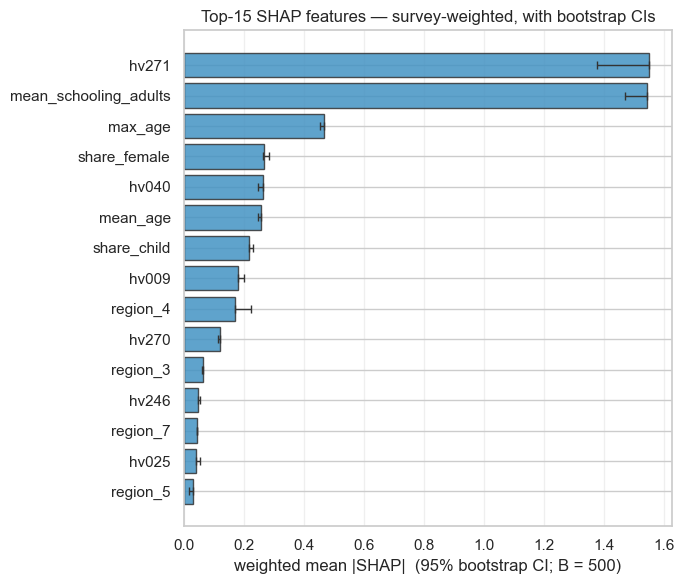

In [13]:
# Plot the top-15 weighted SHAP with bootstrap 95% CI bars
fig, ax = plt.subplots(figsize=(7, 6))
y_pos = np.arange(len(boot_df))[::-1]  # largest at top
ax.barh(y_pos, boot_df["weighted_mean_abs_shap"], color="#4393c3",
        edgecolor="0.2", alpha=0.85)
# Clip to zero — the original-sample point estimate is the sample mean, not
# the bootstrap median, so it can fall fractionally outside the 95% CI bounds
# for features whose bootstrap distribution is skewed (rare; cosmetic).
xerr_lo = np.maximum(0.0, boot_df["weighted_mean_abs_shap"] - boot_df["lo_95"])
xerr_hi = np.maximum(0.0, boot_df["hi_95"] - boot_df["weighted_mean_abs_shap"])
ax.errorbar(
    boot_df["weighted_mean_abs_shap"], y_pos,
    xerr=[xerr_lo, xerr_hi],
    fmt="none", ecolor="0.2", elinewidth=1.0, capsize=3,
)
ax.set_yticks(y_pos)
ax.set_yticklabels(boot_df["feature"])
ax.set_xlabel("weighted mean |SHAP|  (95% bootstrap CI; B = 500)")
ax.set_title("Top-15 SHAP features — survey-weighted, with bootstrap CIs")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
viz.save_figure(fig, "shap_top15_bootstrap_ci")
plt.show()


In [14]:
# Rank-correlation: weighted vs unweighted top-15
unweighted_mean = abs_vals.mean(0)
sm_full = pd.DataFrame({
    "feature": features,
    "unweighted": unweighted_mean,
    "weighted": weighted_mean,
}).sort_values("weighted", ascending=False).head(15)
rho, _ = spearmanr(sm_full["unweighted"], sm_full["weighted"])
print(f"Spearman(unweighted, weighted) on top-15 by weighted = {rho:+.3f}")

# Rank disagreement: how many of the top-5 are different?
top5_w = set(sm_full.head(5)["feature"])
top5_uw = set(sm_full.sort_values("unweighted", ascending=False).head(5)["feature"])
print(f"Top-5 overlap (weighted vs unweighted) = {len(top5_w & top5_uw)} / 5")


Spearman(unweighted, weighted) on top-15 by weighted = +0.968
Top-5 overlap (weighted vs unweighted) = 5 / 5


**Reading.** If the CIs are tight relative to the gaps between adjacent features, the weighted ranking is stable to sampling noise and the national claim is well supported. If the top-3 CIs overlap heavily, the *ordering within the top* should be reported as a tie rather than a strict ranking. The Spearman + top-5 overlap put a number on how much the weighting moves the story: low overlap means the weighting matters a lot for any "in Ethiopia" claim, high overlap means the design weights are a small correction here.

## 6. Full (uncapped) SHAP summary plot

Per the CLAUDE.md hero constraint, `02_main.ipynb` shows the top-15 by mean |SHAP|; the full plot lives here. This is the standard beeswarm: one row per feature, one dot per household, x = signed SHAP value, color = feature value. The full plot lets the reader see direction-of-effect (which side of zero the dots fall on as the feature value changes), not just magnitude.

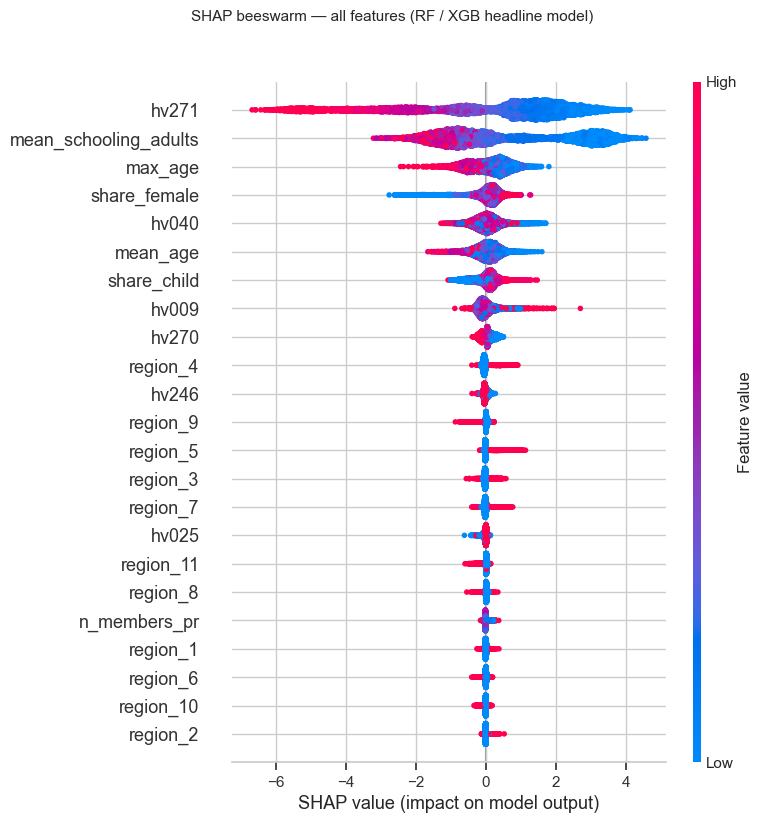

In [15]:
# Full beeswarm with all features. shap.summary_plot doesn't natively take
# sample_weight in the visualisation, but the *ordering* of rows is already
# fixed and the per-feature mean |SHAP| label is what we care about for the
# headline — we've already reported the weighted ranking above; this is the
# distributional view.
shap.summary_plot(
    shap_vals,
    X,
    feature_names=features,
    max_display=len(features),  # uncapped
    show=False,
    plot_size=(8, max(4, 0.35 * len(features))),
)
fig = plt.gcf()
fig.suptitle("SHAP beeswarm — all features (RF / XGB headline model)",
             fontsize=11, y=1.02)
plt.tight_layout()
viz.save_figure(fig, "shap_beeswarm_full")
plt.show()


## Verdict — does the headline survive?

We restate the conclusion of each stress test in one sentence so the reader can audit them against the tables above without re-deriving anything:

1. **Cutoff k.** National MPI moves with k by construction; the regional ranking holds across k ∈ {0.20, 1/3, 0.50} if `Spearman(rank_k=1/3, rank_k=0.20) ≥ ~0.95` and similarly for k = 0.50. The actual values printed in §1 settle this.
2. **Missingness.** This is the load-bearing check (~36% drop). The available-case re-run shows whether the regional ranking is policy-dependent; the rank-shift column and the Spearman in §2 are the audit numbers.
3. **Clustered CV.** The `n_splits` sweep should show stable AUC across {3, 5, 10}; LOO-region quantifies worst-case region-transfer. The headline GroupKFold(5) result is well-supported if the gap is small and the LOO spread isn't pathological.
4. **Wealth circularity.** AUC delta in §4 quantifies how much of the headline classifier's signal is the DHS wealth index alone. A small delta means the rest of the feature set independently recovers most of the signal; the SHAP comparison shows what fills the top slots without wealth.
5. **SHAP weighting.** The bootstrap CIs in §5 say whether the within-top-15 ranking is statistically meaningful or whether several features are effectively tied; the rank correlation says how much the weighting moves the unweighted story.
6. **Full SHAP plot.** Direction-of-effect is visible in §6; the headline's top-15 by mean |SHAP| is a faithful summary of the full plot iff the beeswarm rows beyond rank 15 are visibly thinner than the top ones.
